## Computational Psycholinguistics A3

#### Name - Namrata Baliga
#### Roll Number - 2022101021

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.formula.api import ols
import nltk
from nltk.corpus import wordnet
import string

In [4]:
df = pd.read_csv('processed_RTs.tsv', sep='\t')

grouped_by_word = df.groupby('word')

mean_rt_series = grouped_by_word['RT'].mean()

mean_rt_per_word = mean_rt_series.reset_index(name='mean_RT')

print(mean_rt_per_word)
mean_rt_per_word.to_csv('mean_RT_per_word.tsv', sep='\t', index=False)

mean_rt_per_word['word_length'] = mean_rt_per_word['word'].astype(str).apply(len)


avg_rt_by_length = mean_rt_per_word.groupby('word_length')['mean_RT'].mean().reset_index()

          word     mean_RT
0     'Admiral  426.092105
1          'Ah  323.963415
2       'Based  351.985714
3       'Budge  349.493671
4         'But  341.776471
...        ...         ...
3099      you,  336.218391
3100     you.'  377.931034
3101     you?'  355.048193
3102     young  336.930481
3103      your  308.141618

[3104 rows x 2 columns]


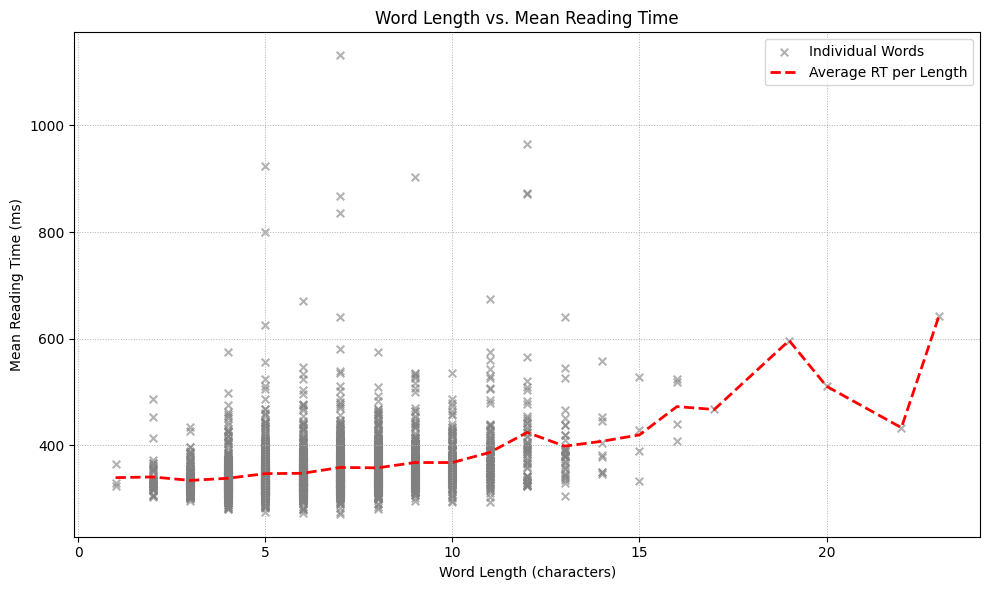

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(mean_rt_per_word['word_length'], mean_rt_per_word['mean_RT'], 
            alpha=0.6, label='Individual Words', marker='x', s=30, color='gray')

plt.plot(avg_rt_by_length['word_length'], avg_rt_by_length['mean_RT'], 
         color='red', linewidth=2, linestyle='--', label='Average RT per Length')

avg_rt_by_length.to_csv('avg_RT_by_length.tsv', sep='\t', index=False)

plt.xlabel('Word Length (characters)')
plt.ylabel('Mean Reading Time (ms)')
plt.title('Word Length vs. Mean Reading Time')

# Use dotted grid
plt.grid(True, linestyle=':', linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()


          word_x     mean_RT  word_length  word_lower      word_y   frequency
0              A  364.203125            1           a           a  3213754375
1           Abby  342.959465            4        abby        Abby      596695
2          About  356.691489            5       about       about   265782619
3      According  321.565789            9   according   according    23748845
4     Accounting  340.887324           10  accounting  Accounting     1871888
...          ...         ...          ...         ...         ...         ...
1967       years  357.113586            5       years       years   114423406
1968      yelled  347.904255            6      yelled      yelled     1620781
1969      yellow  412.474359            6      yellow      yellow     7043215
1970       young  336.930481            5       young       young    42619892
1971        your  308.141618            4        your        your   205261264

[1972 rows x 6 columns]


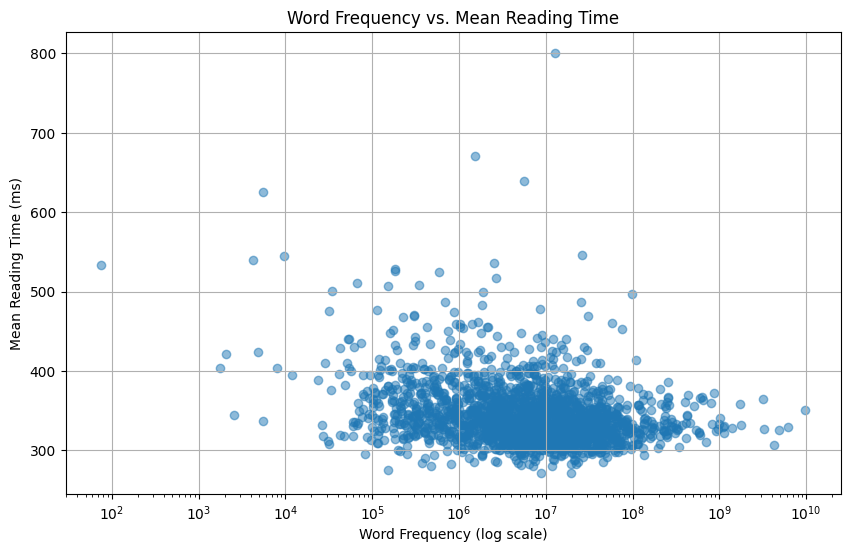

In [6]:
freq_1gram = pd.read_csv('freqs-1.tsv', sep='\t', header=None)
freq_1gram.columns = ['token_code', 'ngram_order', 'token', 'ngram_freq', 'context_freq']


freq_clean = freq_1gram[['token', 'ngram_freq']].copy()

freq_clean = freq_clean.rename(columns={'token': 'word', 'ngram_freq': 'frequency'})

freq_clean['word_lower'] = freq_clean['word'].astype(str).str.lower()

mean_rt_per_word['word_lower'] = mean_rt_per_word['word'].str.lower()

mean_rt_per_word_unique = mean_rt_per_word.drop_duplicates(subset='word_lower')
freq_clean_unique = freq_clean.drop_duplicates(subset='word_lower')


merged_df = pd.merge(mean_rt_per_word_unique, freq_clean_unique, on='word_lower', how='inner')

print(merged_df)

plt.figure(figsize=(10, 6))
plt.scatter(merged_df['frequency'], merged_df['mean_RT'], alpha=0.5)
plt.xscale('log')  
plt.xlabel('Word Frequency (log scale)')
plt.ylabel('Mean Reading Time (ms)')
plt.title('Word Frequency vs. Mean Reading Time')
plt.grid(True)
plt.show()



In [7]:
mean_rt_per_word.to_csv('mean_RT_per_word.tsv', sep='\t', index=False)
merged_df.to_csv('merged_df.tsv', sep='\t', index=False)
freq_clean_unique.to_csv('freq_clean.tsv', sep='\t', index=False)

corr, p_value = pearsonr(merged_df['word_length'], merged_df['frequency'])

print(f"Pearson's r (Word Length vs Frequency): {corr:.4f}")
print(f"P-value: {p_value:.4e}")

corr_length_rt, p_value = pearsonr(merged_df['word_length'], merged_df['mean_RT'])


print(f"Pearson's r (Word Length vs Mean RT): {corr_length_rt:.4f}")
print(f"P-value: {p_value:.4e}")

corr_length_rt, p_value = pearsonr(merged_df['frequency'], merged_df['mean_RT'])


print(f"Pearson's r (Frequency vs Mean RT): {corr_length_rt:.4f}")
print(f"P-value: {p_value:.4e}")

Pearson's r (Word Length vs Frequency): -0.1769
P-value: 2.4807e-15
Pearson's r (Word Length vs Mean RT): 0.2355
P-value: 2.9007e-26
Pearson's r (Frequency vs Mean RT): -0.0321
P-value: 1.5424e-01


- A negative correlation shows that shorter words tend to have higher frequency, consistent with well‐known patterns in English that common words are often shorter.
- A moderate positive correlation indicates that longer words generally incur longer reading times. This is straightforward: more letters or syllables typically take more time to process.
- A very weak negative correlation suggests that more frequent words may be read slightly faster, but here it is not statistically significant.

- Word length appears to be a more reliable predictor of reading time, while word frequency shows only a faint trend that does not reach statistical significance in this sample.